<a href="https://colab.research.google.com/github/mariavyzhletsova-gif/lyceum_saturday10_2025/blob/master/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import math
from collections import Counter
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [9]:
class MyKNN:
    def __init__(self, k=3, metric='euclidean'):
        self.k = k
        self.metric = metric
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def _euclidean(self, a, b):
        return math.sqrt(sum((a[i] - b[i])**2 for i in range(len(a))))

    def _manhattan(self, a, b):
        return sum(abs(a[i] - b[i]) for i in range(len(a)))

    def _predict_one(self, x):
        distances = []
        for i in range(len(self.X_train)):
            if self.metric == 'euclidean':
                d = self._euclidean(x, self.X_train[i])
            else:
                d = self._manhattan(x, self.X_train[i])
            distances.append((d, self.y_train[i]))
        distances.sort(key=lambda t: t[0])
        neighbors = [distances[j][1] for j in range(self.k)]
        return Counter(neighbors).most_common(1)[0][0]

    def predict(self, X):
        return [self._predict_one(x) for x in X]

In [10]:
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=True, stratify=y, random_state=42
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"Class distribution in train: {sum(y_train==0)}, {sum(y_train==1)}, {sum(y_train==2)}")
print(f"Class distribution in test: {sum(y_test==0)}, {sum(y_test==1)}, {sum(y_test==2)}")

Train size: 105, Test size: 45
Class distribution in train: 35, 35, 35
Class distribution in test: 15, 15, 15


In [11]:
my_knn = MyKNN(k=3, metric='euclidean')
my_knn.fit(X_train, y_train)
y_pred = my_knn.predict(X_test)

my_accuracy = accuracy_score(y_test, y_pred)
print(f"My KNN accuracy: {my_accuracy:.4f}")

My KNN accuracy: 0.9556


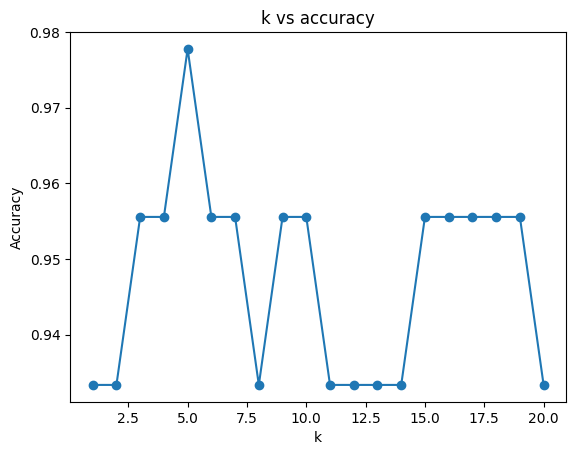

Best k = 5, accuracy = 0.9778


In [12]:
import matplotlib.pyplot as plt

k_tests = range(1, 21)
accuracies = []

for k in k_tests:
    knn = MyKNN(k=k, metric='euclidean')
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, preds))

plt.plot(k_tests, accuracies, 'o-')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('k vs accuracy')
plt.show()

best_k = k_tests[accuracies.index(max(accuracies))]
print(f"Best k = {best_k}, accuracy = {max(accuracies):.4f}")

In [13]:
sklearn_knn = KNeighborsClassifier(n_neighbors=3)
sklearn_knn.fit(X_train, y_train)
sklearn_preds = sklearn_knn.predict(X_test)
sklearn_accuracy = accuracy_score(y_test, sklearn_preds)

print(f"sklearn KNN accuracy: {sklearn_accuracy:.4f}")
print(f"My KNN accuracy: {my_accuracy:.4f}")
print(f"Difference: {abs(sklearn_accuracy - my_accuracy):.4f}")

sklearn KNN accuracy: 0.9556
My KNN accuracy: 0.9556
Difference: 0.0000


In [14]:
min_vals = X_train.min(axis=0)
max_vals = X_train.max(axis=0)
X_train_norm = (X_train - min_vals) / (max_vals - min_vals)
X_test_norm = (X_test - min_vals) / (max_vals - min_vals)

knn_norm = MyKNN(k=3, metric='euclidean')
knn_norm.fit(X_train_norm, y_train)
preds_norm = knn_norm.predict(X_test_norm)
norm_accuracy = accuracy_score(y_test, preds_norm)

print(f"Without normalization: {my_accuracy:.4f}")
print(f"With normalization: {norm_accuracy:.4f}")

Without normalization: 0.9556
With normalization: 0.9333
